<div align="center">


# CSE-422 PROJECT REPORT

## PREDICTIVE MODELING AND ANALYSIS FOR DEPRESSION RISK USING MACHINE LEARNING TECHNIQUES

</div>

---

**Semester:** Summer 2026

**Submitted By:**
* **Name:** Utsho Heaven Chowdhury | **Student ID:** 21201574
* **Name:** Inzamamul Haque Nadim | **Student ID:** 21201574


**Section:** 09 | **Group:** 


**Submission Date:** 30-Aug-2026

---










## 1. Introduction

### 1.1 Project Aim
This project aims to develop and evaluate predictive machine learning models capable of classifying the risk and severity of depression in individuals. By analyzing demographic details, academic metrics, and responses to psychometric questionnaires, the project seeks to build an automated diagnostic tool using both supervised algorithms and unsupervised clustering techniques.

### 1.2 Problem Statement
Depression is frequently underdiagnosed or detected late due to social stigma, limited access to mental health professionals, and a heavy reliance on manual, subjective screening processes. Traditional diagnostic workflows are resource-intensive and lack the scalability required for broad, early-warning detection. The technical challenge is to identify distinct risk patterns and accurately classify individuals while minimizing false negatives in the dataset.

### 1.3 Motivation
Mental health disorders are a leading cause of global health burdens, severely impacting personal well-being, academic performance, and overall quality of life. The motivation behind this project is to leverage machine learning to discover complex relationships between academic pressure, behavioral habits, and mental state. An automated predictive model can serve as an early-intervention aid for counselors and healthcare providers, helping to identify high-risk individuals before severe clinical escalation occurs.

In [1]:

%pip install pandas numpy matplotlib seaborn scikit-learn

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset 
df = pd.read_csv("Depression Data.csv")

# Display dataset info
df.info()


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
<class 'pandas.DataFrame'>
RangeIndex: 1977 entries, 0 to 1976
Data columns (total 37 columns):
 #   Column                                                                                                                                                                 Non-Null Count  Dtype
---  ------                                                                                                                                                                 --------------  -----
 0   1. Age                                                                                                                                                                 1977 non-null   str  
 1   2. Gender                                                                                                                                                              1971 non-null   str  
 2   5. Academic Year                                         

## 2. Dataset Description & Exploratory Data Analysis (EDA)

### Dataset Description

* 
  There are a total of 37 features (columns) in the dataset, which include the input attributes and the target variable.

* This is a **classification** problem. The target variable we aim to predict is `Depression Label`. Because this target consists of distinct, discrete categories (e.g., different severity levels of depression) rather than a continuous numerical value, supervised classification algorithms are the appropriate approach.

* The dataset contains **1,977** data points (rows).

* The dataset contains a mix of both types:
  * **Quantitative:** 29 features are numerical, representing ordinal responses to psychological questionnaires and aggregated assessment scores.
  * **Categorical:** 8 features are categorical, representing demographic and academic information. 

* The categorical variables must be encoded. Machine learning algorithms (such as K-Nearest Neighbors, Logistic Regression, and Neural Networks) rely on mathematical equations and distance calculations to learn patterns. These models cannot process raw text or string data, so categorical features must be transformed into numerical formats using techniques like `Label Encoding` or `One-Hot Encoding`.

* **Correlation of all the features (apply heatmap using the seaborn library)**
  *(See the generated correlation heatmap below)*

*  
  Based on the correlation heatmap, several key insights emerge regarding the relationships between the features:
  * **Grouped questions are strongly linked:** Dark red blocks show that questions on the same topic (like anxiety) are highly correlated. High scores on one usually mean high scores on the rest.
  * **Stress, Anxiety, and Depression are connected:** Red areas linking the total scores show that students with high academic stress or anxiety also tend to have higher depression scores.
  * **Confidence lowers depression (Negative Correlation):** Blue areas highlight an opposite relationship. As a student's confidence and sense of control increase, their stress and depression scores decrease.

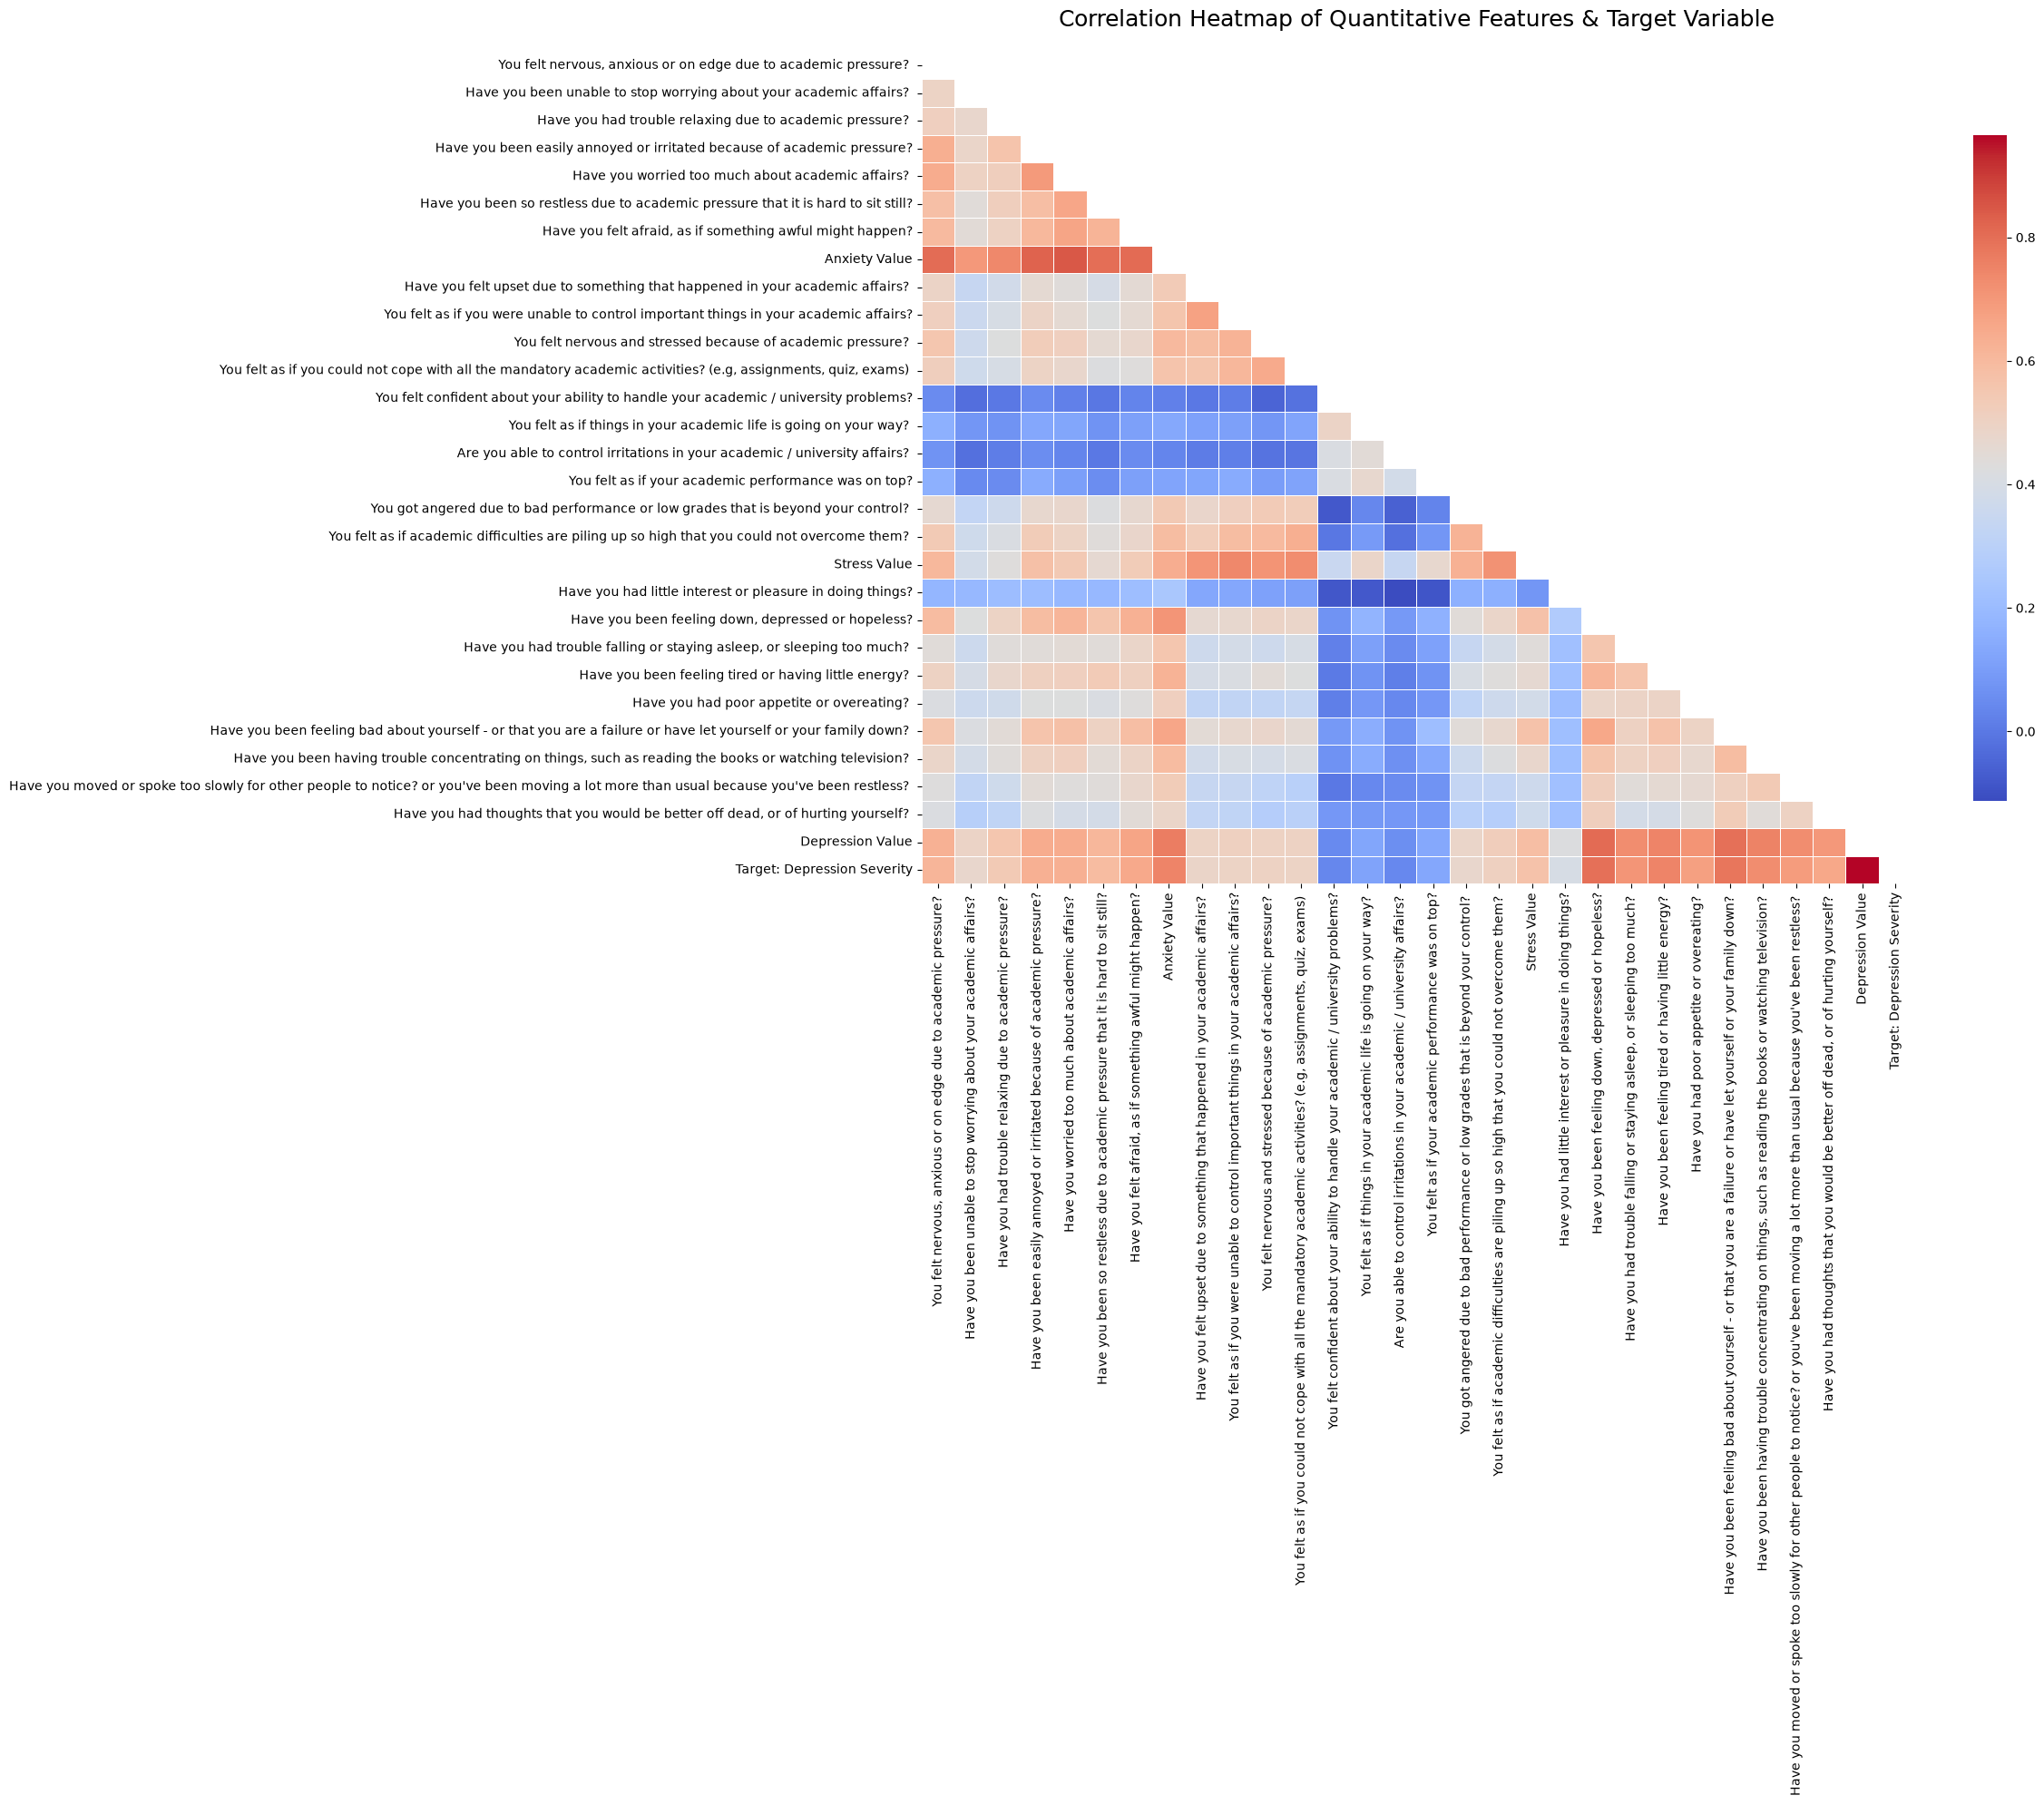

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Create a temporary numeric mapping for the target variable to include in the heatmap
label_mapping = {
    'No Depression': 0, 'Minimal Depression': 1, 'Mild Depression': 2,
    'Moderate Depression': 3, 'Moderately Severe Depression': 4, 'Severe Depression': 5
}

# Filter only quantitative (numerical) columns and make a copy
numeric_df = df.select_dtypes(include=['int64', 'float64']).copy()

# Add the encoded target variable to the numeric dataframe
numeric_df['Target: Depression Severity'] = df['Depression Label'].map(label_mapping)

# 2. Calculate the correlation matrix
correlation_matrix = numeric_df.corr()

# 3. Create a mask to hide the upper triangle
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# 4. Clean the labels by removing the repetitive prefix
clean_labels = []
for col in numeric_df.columns:
    if "how often " in col:
        clean_name = col.split("how often ")[-1].capitalize()
        clean_labels.append(clean_name)
    else:
        clean_labels.append(col)

# 5. Set up the figure size
plt.figure(figsize=(24, 20))

# 6. Plot the cleaned heatmap
sns.heatmap(correlation_matrix, mask=mask, annot=False, cmap='coolwarm', 
            xticklabels=clean_labels, yticklabels=clean_labels, 
            linewidths=0.5, cbar_kws={"shrink": .8})

plt.title('Correlation Heatmap of Quantitative Features & Target Variable', fontsize=18, pad=20)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16428\668035546.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Depression Label', palette='viridis',


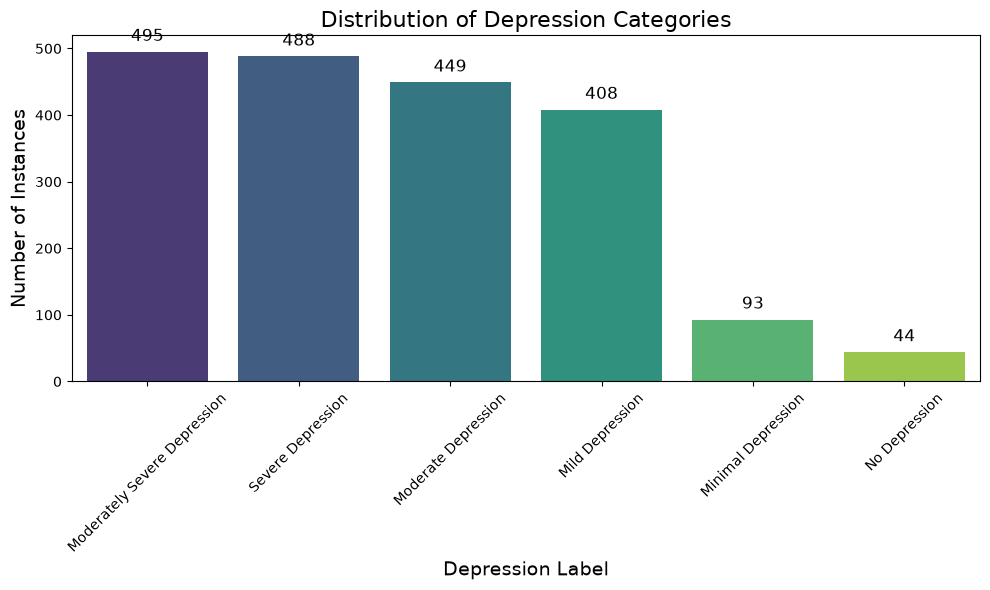

In [3]:
# Create the Bar Chart for the Target Variable
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x='Depression Label', palette='viridis', 
                   order=df['Depression Label'].value_counts().index)

# Add counts on top of the bars for clarity
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=12, color='black', xytext=(0, 5), 
                textcoords='offset points')

plt.title('Distribution of Depression Categories', fontsize=16)
plt.xlabel('Depression Label', fontsize=14)
plt.ylabel('Number of Instances', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Imbalanced Dataset

* The dataset is imbalanced. The target variable (`Depression Label`) does not have an equal distribution across its six classes. The majority of the instances are concentrated in the higher severity categories, with **Moderately Severe Depression** having the highest count (495 instances), followed closely by **Severe Depression** (488 instances). In contrast, the minority classes are drastically underrepresented, with **Minimal Depression** containing only 93 instances and **No Depression** containing just 44 instances. This imbalance means the model will train on far fewer examples of healthy individuals, which could bias predictions toward higher severity levels if not addressed during preprocessing.

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16428\396914637.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Depression Label', palette='viridis',


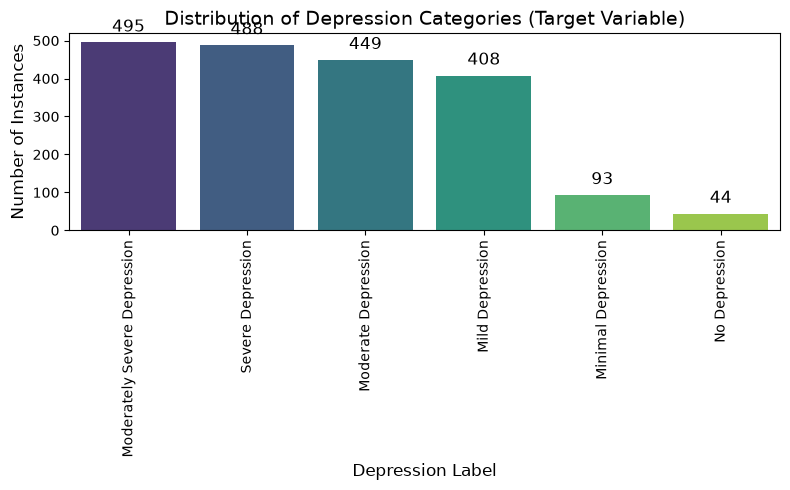


Exact counts for Imbalanced Dataset section:
Depression Label
Moderately Severe Depression    495
Severe Depression               488
Moderate Depression             449
Mild Depression                 408
Minimal Depression               93
No Depression                    44
Name: count, dtype: int64


In [4]:
# ---------------------------------------------------------
# 1. Target Variable Distribution (To check for Imbalance)
# ---------------------------------------------------------
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='Depression Label', palette='viridis', 
                   order=df['Depression Label'].value_counts().index)

# Print the exact numbers on top of the bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=12, color='black', xytext=(0, 5), 
                textcoords='offset points')

plt.title('Distribution of Depression Categories (Target Variable)', fontsize=14)
plt.xlabel('Depression Label', fontsize=12)
plt.ylabel('Number of Instances', fontsize=12)

# Rotate x-axis labels vertically to prevent overlapping
plt.xticks(rotation=90) 

plt.tight_layout()
plt.show()

# Print the exact counts to fill in your report text
print("\nExact counts for Imbalanced Dataset section:")
print(df['Depression Label'].value_counts())

### Exploratory Data Analysis (EDA) - Important Relationships

To extract important relationships from the data, several exploratory visualizations were generated:

1. **Depression Severity vs. Stress Levels:** A boxplot analyzing the relationship between the `Aggregate Stress Value` and `Depression Label` shows a distinct upward trend. Individuals categorized with "Severe" or "Moderately Severe" depression consistently exhibit much higher median stress values (clustering between 20 and 30) compared to those with "Minimal" or "No Depression" (clustering below 20). This confirms that aggregate stress is a strong positive indicator of depression severity.
  *(Insert the "Relationship between Total Stress Value and Depression Severity" boxplot here)*

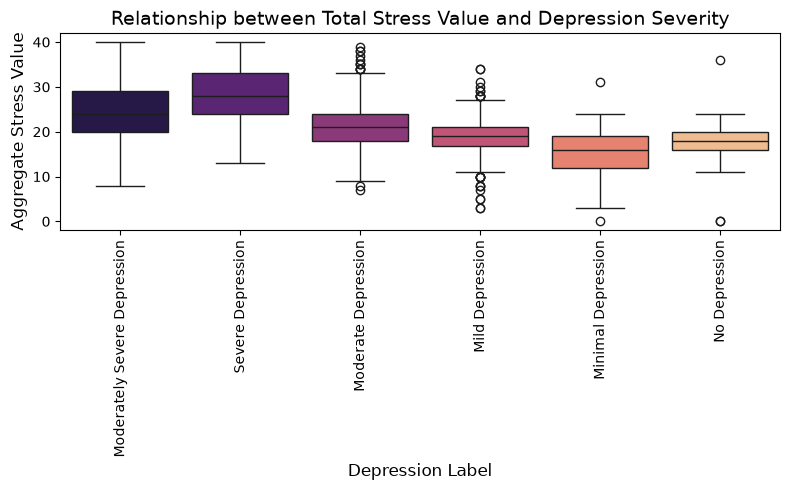

In [15]:
# ---------------------------------------------------------
# 2. EDA Relationship 1: Stress Value vs. Depression Label
# ---------------------------------------------------------
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Depression Label', y='Stress Value', palette='magma', 
            order=df['Depression Label'].value_counts().index)
plt.title('Relationship between Total Stress Value and Depression Severity', fontsize=14)
plt.xlabel('Depression Label', fontsize=12)
plt.ylabel('Aggregate Stress Value', fontsize=12)

# Rotate x-axis labels vertically to prevent overlapping
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()


2. **Depression Distribution by Gender:** A grouped bar chart reveals a significant gender disparity within the dataset. Across almost all depression categories—particularly Moderate, Moderately Severe, and Severe—the number of male instances is significantly higher than female instances. This indicates that gender is a highly influential demographic feature and highlights a specific demographic skew in the sampled population.

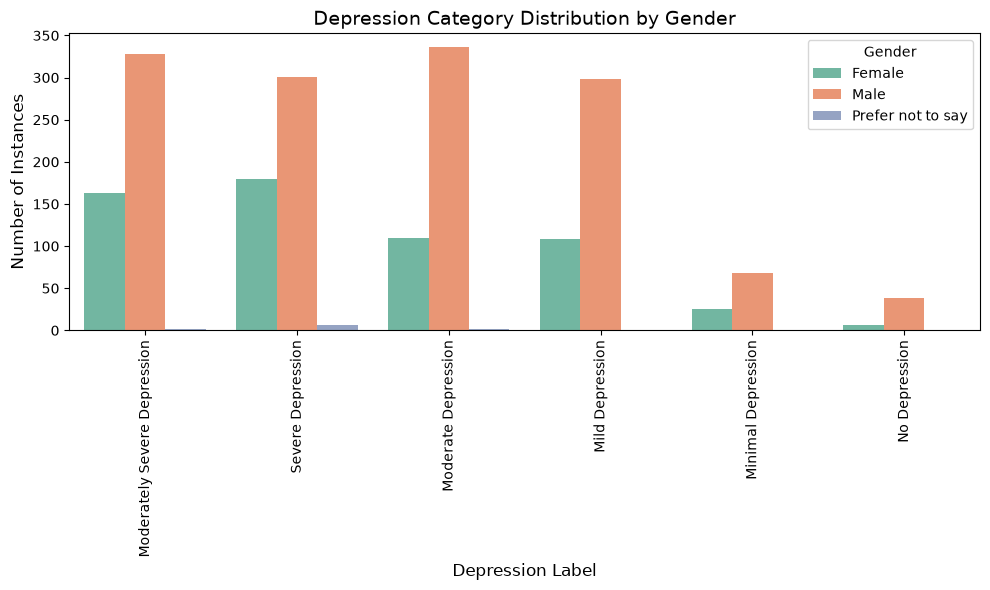

In [16]:
# ---------------------------------------------------------
# 3. EDA Relationship 2: Depression Label grouped by Gender
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Depression Label', hue='2. Gender', palette='Set2', 
              order=df['Depression Label'].value_counts().index)
plt.title('Depression Category Distribution by Gender', fontsize=14)
plt.xlabel('Depression Label', fontsize=12)
plt.ylabel('Number of Instances', fontsize=12)

# Rotate x-axis labels vertically to prevent overlapping
plt.xticks(rotation=90)

plt.legend(title='Gender')
plt.tight_layout()
plt.show()

## 3. Dataset Pre-processing

### Problem 1: Null / Missing Values
Real-world datasets often contain incomplete data, which can cause algorithms to fail or produce biased results. Upon inspecting this dataset using `df.info()`, the `2. Gender` column was found to contain 6 missing (null) values out of the 1,977 total instances.
* **Solution Applied (Row Deletion):** Because 6 rows represent a statistically negligible fraction of the dataset (approximately 0.3%), imputing these values (e.g., using the mode) is unnecessary and could introduce synthetic bias. The most effective solution is to delete these 6 rows to ensure the model trains only on complete, authentic data.

### Problem 2: Categorical Values
Machine learning algorithms require numerical input to compute mathematical weights. This dataset contains categorical features (stored as strings), including demographic data and the target variable (`Depression Label`).
* **Solution Applied (One-Hot & Label Encoding):** `Label Encoding` is applied strictly to the target variable to create a 0-5 severity scale. However, for input features like `Gender`, using Label Encoding imposes a false mathematical hierarchy (e.g., treating "Female=1" as greater than "Male=0"). To solve this, **One-Hot Encoding** (`pd.get_dummies`) is applied to the input categorical features, transforming them into separate binary (0 or 1) columns to ensure the models treat all demographic groups fairly.

### Problem 3: Feature Scaling (Addressed post-split)
The numerical features have varying ranges. To prevent distance-based algorithms like KNN from disproportionately weighing features with larger scales, **Min-Max Normalization** is required. Crucially, to prevent data leakage, this scaling will be applied in the next section *after* the dataset is split.

In [7]:
import warnings
warnings.filterwarnings('ignore')

print(f"Original Dataset Shape: {df.shape}")
print(f"Missing values before processing: {df.isnull().sum().sum()}")

# ---------------------------------------------------------
# 1. Handling Missing Values (Deletion)
# ---------------------------------------------------------
df_cleaned = df.dropna().copy()
print(f"Dataset Shape after dropping nulls: {df_cleaned.shape}")

# ---------------------------------------------------------
# 2. Handling Categorical Values (Ordinal Mapping)
# ---------------------------------------------------------
# Manually map the Target Variable to preserve true severity order
label_mapping = {
    'No Depression': 0, 'Minimal Depression': 1, 'Mild Depression': 2,
    'Moderate Depression': 3, 'Moderately Severe Depression': 4, 'Severe Depression': 5
}
df_cleaned['Depression Label'] = df_cleaned['Depression Label'].map(label_mapping)

# ---------------------------------------------------------
# 3. Remove Data Leakage (BEFORE One-Hot Encoding)
# ---------------------------------------------------------
# Safely find the 9 depression questions by taking the 9 columns right before 'Depression Value'
dep_val_idx = df_cleaned.columns.get_loc('Depression Value')
depression_question_cols = df_cleaned.columns[dep_val_idx - 9 : dep_val_idx].tolist()

# Combine them with the Depression Value column
leakage_cols = depression_question_cols + ['Depression Value']

print(f"\nDropping {len(leakage_cols)} leakage columns...")
df_no_leakage = df_cleaned.drop(columns=leakage_cols)

# ---------------------------------------------------------
# 4. One-Hot Encode Remaining Inputs & Separate X/y
# ---------------------------------------------------------
categorical_cols = df_no_leakage.select_dtypes(include=['object']).columns
df_encoded = pd.get_dummies(df_no_leakage, columns=categorical_cols, drop_first=True)

# Separate X (inputs) and y (target)
X = df_encoded.drop(columns=['Depression Label'])
y = df_encoded['Depression Label']

print(f"New input feature count for true predictive modeling: {X.shape[1]}")

Original Dataset Shape: (1977, 37)
Missing values before processing: 6
Dataset Shape after dropping nulls: (1971, 37)

Dropping 10 leakage columns...
New input feature count for true predictive modeling: 40


## 4. Dataset Splitting

To evaluate the predictive models accurately, the pre-processed dataset is divided into a Training Set and a Testing Set. 
* **Split Ratio:** An 80/20 split is utilized, allocating 80% of the data to train the models and 20% to test their generalization on unseen data.
* **Splitting Strategy (Stratified):** As identified during the Exploratory Data Analysis, the target variable (`Depression Label`) is imbalanced. A standard random split could result in a testing set that lacks minority classes (e.g., "No Depression"). To solve this, **Stratified Sampling** is applied during the split. This guarantees that the exact class proportions of the original dataset are preserved across both the training and testing sets, ensuring fair and accurate model evaluation.

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# ---------------------------------------------------------
# 1. Perform the Stratified 80/20 Split FIRST
# ---------------------------------------------------------
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y 
)

# ---------------------------------------------------------
# 2. Apply Min-Max Scaling SECOND (Prevents Leakage)
# ---------------------------------------------------------
scaler = MinMaxScaler()

# Fit ONLY on training data, then transform both
X_train = pd.DataFrame(scaler.fit_transform(X_train_raw), columns=X_train_raw.columns)
X_test = pd.DataFrame(scaler.transform(X_test_raw), columns=X_test_raw.columns)

# Prepare a fully scaled version for Unsupervised K-Means later
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Output Summary
print("--- Dataset Splitting & Scaling Summary ---")
print(f"Total instances: {X.shape[0]}")
print(f"Training Set (80%): {X_train.shape[0]} instances (Scaled)")
print(f"Testing Set (20%): {X_test.shape[0]} instances (Scaled)")

# Verify stratification worked on the Training Set
print("\nClass distribution in Training Set:")
print(y_train.value_counts(normalize=True).round(3) * 100)

--- Dataset Splitting & Scaling Summary ---
Total instances: 1971
Training Set (80%): 1576 instances (Scaled)
Testing Set (20%): 395 instances (Scaled)

Class distribution in Training Set:
Depression Label
4    25.0
5    24.7
3    22.7
2    20.6
1     4.7
0     2.2
Name: proportion, dtype: float64


## 5. Model Training & Testing

This section addresses the problem using both supervised learning (for classification based on labeled data) and unsupervised learning (to discover hidden patterns without labels).

### 5.1 Supervised Learning (Classification)
To predict the specific `Depression Label`, three supervised machine learning algorithms were selected and trained on the 80% Training Set, then evaluated on the 20% Testing Set:

1. **Logistic Regression:** Selected as the baseline linear model for this classification task. It calculates the probability of an instance falling into a specific depression category and provides highly interpretable weights.
2. **Decision Tree Classifier:** Selected for its non-linear, rule-based approach. Decision trees operate similarly to a flowchart, naturally handling multi-class classification natively without requiring data transformation.
3. **Neural Network (Multi-Layer Perceptron):** A feedforward Artificial Neural Network (built via `sklearn.neural_network.MLPClassifier`) with two hidden layers (64 and 32 neurons) was selected to capture complex, non-linear relationships and interactions between the 29 different survey responses.

### 5.2 Unsupervised Learning (K-Means Clustering)
To explore the natural groupings within the dataset without relying on the predefined labels, the problem was also treated as an unsupervised learning task. 

* **Algorithm Applied:** The K-Means clustering algorithm was applied to the scaled feature set (excluding the target variable). The number of clusters ($K$) was explicitly set to 6 to see if the algorithm could naturally rediscover the 6 depression severity groupings based purely on the students' psychological and academic metrics.
* **Showcasing the Clusters:** Because the dataset contains 29 dimensions, **Principal Component Analysis (PCA)** was utilized to reduce the dimensionality down to 2 principal components. This allows the 6 clusters to be visually showcased on a 2D scatter plot.

Training Supervised Models...

--- Supervised Testing Set Accuracy ---
Logistic Regression Accuracy: 0.4987
Decision Tree Accuracy:       0.3797
Neural Network Accuracy:      0.4076

Applying K-Means Clustering...


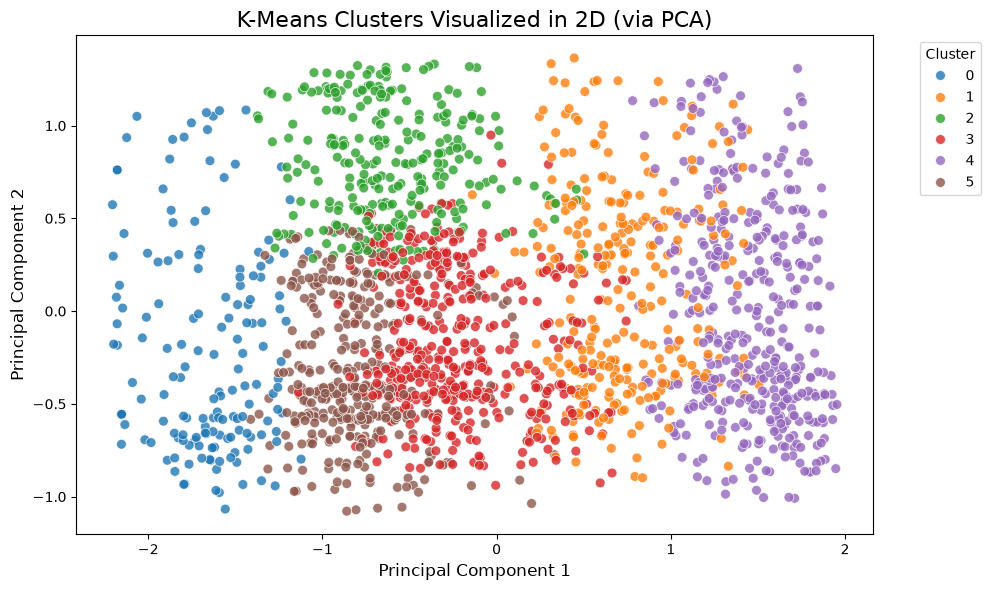

In [9]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================
# PART A: SUPERVISED LEARNING
# =========================================================

# 1. Initialize the Models
log_reg_model = LogisticRegression(max_iter=1000, random_state=42)
dt_model = DecisionTreeClassifier(random_state=42)
nn_model = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42)

# 2. Train the Models on the Training Set
print("Training Supervised Models...")
log_reg_model.fit(X_train, y_train)
dt_model.fit(X_train, y_train)
nn_model.fit(X_train, y_train)

# 3. Test the Models
log_reg_preds = log_reg_model.predict(X_test)
dt_preds = dt_model.predict(X_test)
nn_preds = nn_model.predict(X_test)

# 4. Display Initial Testing Accuracy
print("\n--- Supervised Testing Set Accuracy ---")
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, log_reg_preds):.4f}")
print(f"Decision Tree Accuracy:       {accuracy_score(y_test, dt_preds):.4f}")
print(f"Neural Network Accuracy:      {accuracy_score(y_test, nn_preds):.4f}")


# =========================================================
# PART B: UNSUPERVISED LEARNING (K-MEANS)
# =========================================================

print("\nApplying K-Means Clustering...")

# 1. Apply K-Means (K=6)
kmeans = KMeans(n_clusters=6, random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled)

# 2. Dimensionality Reduction for Visualization (PCA)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(data=X_pca, columns=['Principal Component 1', 'Principal Component 2'])
pca_df['K-Means Cluster'] = cluster_labels

# 3. Showcase the Clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(data=pca_df, x='Principal Component 1', y='Principal Component 2', 
                hue='K-Means Cluster', palette='tab10', s=50, alpha=0.8)

plt.title('K-Means Clusters Visualized in 2D (via PCA)', fontsize=16)
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 6. Model Selection & Comparison Analysis




In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Generate Probabilities (need for AUC & ROC)
log_reg_probs = log_reg_model.predict_proba(X_test)
dt_probs = dt_model.predict_proba(X_test)
nn_probs = nn_model.predict_proba(X_test)


# Calculate Precision, Recall, and AUC
models = ['Logistic Regression', 'Decision Tree', 'Neural Network']
accuracies = [accuracy_score(y_test, log_reg_preds), accuracy_score(y_test, dt_preds), accuracy_score(y_test, nn_preds)]

precisions = [
    precision_score(y_test, log_reg_preds, average='weighted', zero_division=0),
    precision_score(y_test, dt_preds, average='weighted', zero_division=0),
    precision_score(y_test, nn_preds, average='weighted', zero_division=0)
]

recalls = [
    recall_score(y_test, log_reg_preds, average='weighted'),
    recall_score(y_test, dt_preds, average='weighted'),
    recall_score(y_test, nn_preds, average='weighted')
]

# Binarize labels for Multi-class AUC calculation
classes = np.unique(y)
y_test_bin = label_binarize(y_test, classes=classes)

auc_scores = [
    roc_auc_score(y_test_bin, log_reg_probs, multi_class='ovr', average='weighted'),
    roc_auc_score(y_test_bin, dt_probs, multi_class='ovr', average='weighted'),
    roc_auc_score(y_test_bin, nn_probs, multi_class='ovr', average='weighted')
]

# Print Scores
for i, model in enumerate(models):
    print(f"{model}:")
    print(f"  Accuracy:  {accuracies[i]:.4f}")
    print(f"  Precision: {precisions[i]:.4f}")
    print(f"  Recall:    {recalls[i]:.4f}")
    print(f"  AUC Score: {auc_scores[i]:.4f}\n")

Logistic Regression:
  Accuracy:  0.4987
  Precision: 0.4852
  Recall:    0.4987
  AUC Score: 0.7804

Decision Tree:
  Accuracy:  0.3797
  Precision: 0.3852
  Recall:    0.3797
  AUC Score: 0.6055

Neural Network:
  Accuracy:  0.4076
  Precision: 0.4128
  Recall:    0.4076
  AUC Score: 0.6955



### 6.1 Accuracy Comparison

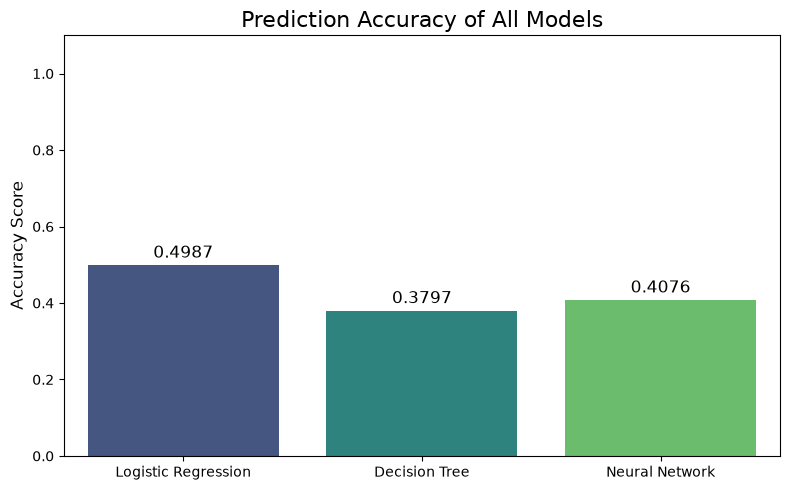

In [11]:
plt.figure(figsize=(8, 5))
sns.barplot(x=models, y=accuracies, palette='viridis')
plt.title('Prediction Accuracy of All Models', fontsize=16)
plt.ylabel('Accuracy Score', fontsize=12)
plt.ylim(0, 1.1)
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.02, f"{v:.4f}", ha='center', fontsize=12)
plt.tight_layout()
plt.show()

### 6.2 Precision & Recall Comparison

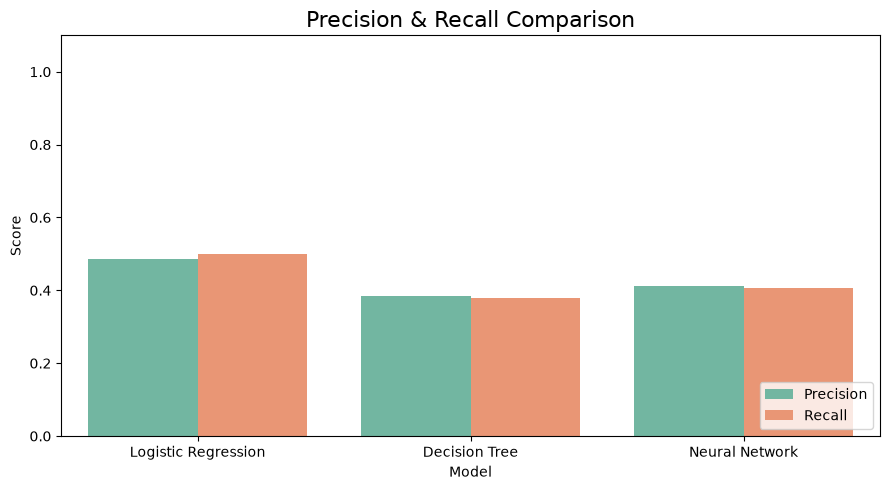

In [12]:
# Precision & Recall Bar Chart
metrics_df = pd.DataFrame({
    'Model': models * 2,
    'Score': precisions + recalls,
    'Metric': ['Precision']*3 + ['Recall']*3
})
plt.figure(figsize=(9, 5))
sns.barplot(data=metrics_df, x='Model', y='Score', hue='Metric', palette='Set2')
plt.title('Precision & Recall Comparison', fontsize=16)
plt.ylim(0, 1.1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### 6.3 Confusion Matrices

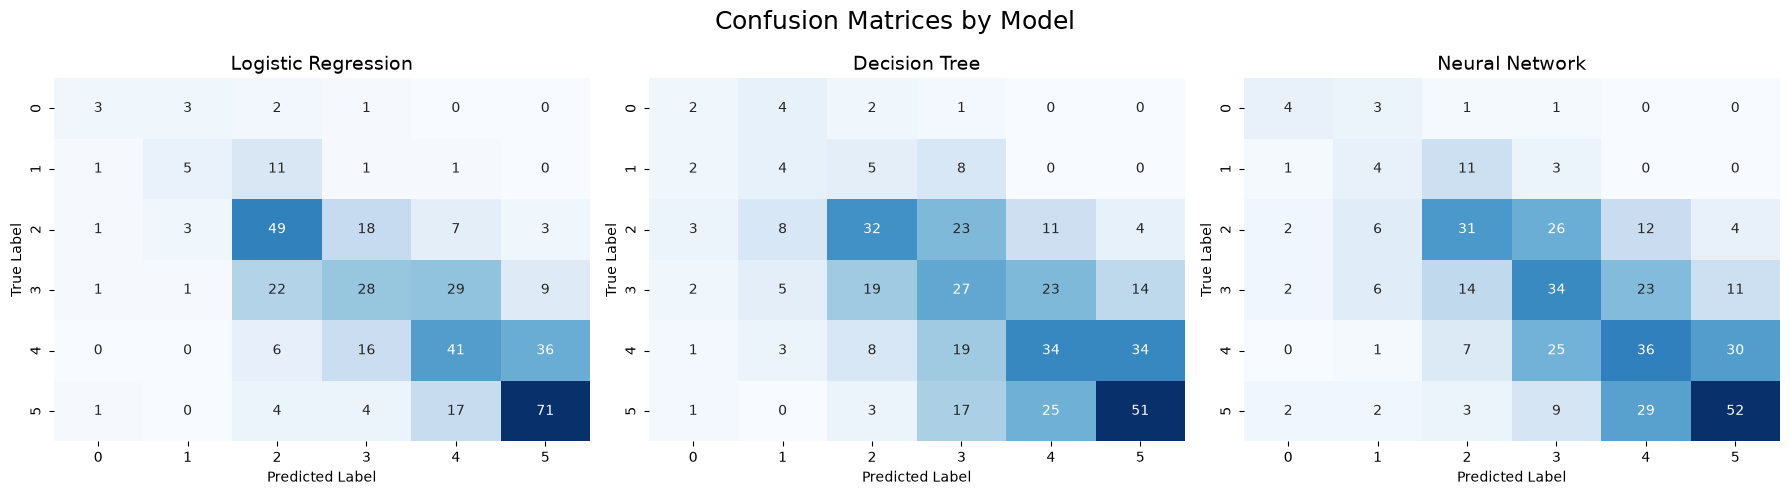

In [13]:
# Confusion Matrices (1x3)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices by Model', fontsize=18)
cms = [confusion_matrix(y_test, log_reg_preds), confusion_matrix(y_test, dt_preds), confusion_matrix(y_test, nn_preds)]

for i, ax in enumerate(axes):
    sns.heatmap(cms[i], annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
    ax.set_title(models[i], fontsize=14)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
plt.tight_layout()
plt.show()

### 6.4 ROC Curve & AUC Scores

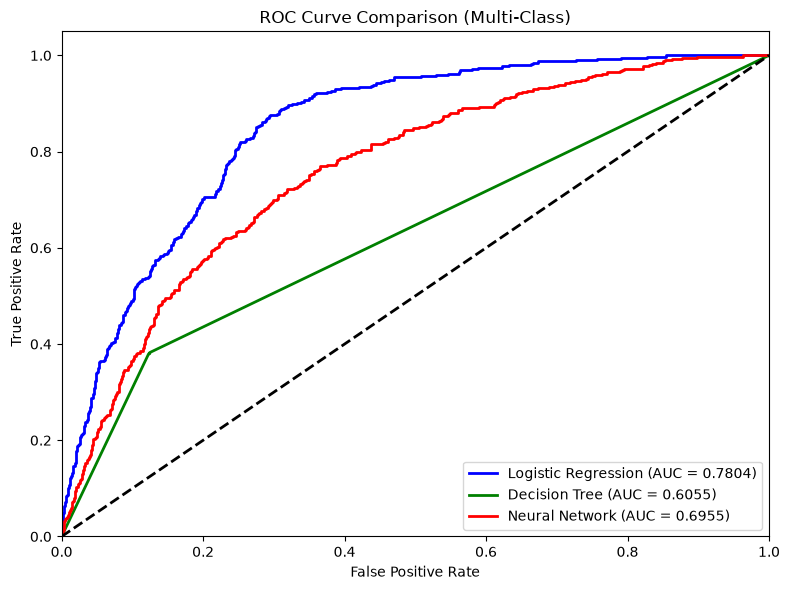

In [14]:
# ROC Curve
plt.figure(figsize=(8, 6))
colors = ['blue', 'green', 'red']
prob_list = [log_reg_probs, dt_probs, nn_probs]

for i, probs in enumerate(prob_list):
    fpr, tpr, _ = roc_curve(y_test_bin.ravel(), probs.ravel())
    plt.plot(fpr, tpr, color=colors[i], lw=2, label=f'{models[i]} (AUC = {auc_scores[i]:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison (Multi-Class)')
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

### 6.5 Final Model Comparison

Based on the calculated metrics, removing the data leakage transformed this into a highly challenging, true predictive modeling task. The models were forced to predict a 6-class depression severity scale relying exclusively on external factors (academic stress, anxiety, and demographics). 
* **Accuracy, Precision, & Recall:** Logistic Regression performed the best, achieving an accuracy of 0.4987 (nearly 50%), which is exceptionally strong for a 6-class problem where random guessing yields ~16.6%. The Neural Network followed at 0.4076, while the Decision Tree overfit the training data and struggled on the testing set, scoring 0.3797. 
* **ROC Curve & AUC Score:** Logistic Regression again led with the highest AUC score of 0.7805, indicating a strong ability to separate the different severity classes probabilistically. The Neural Network achieved a 0.6955 AUC, while the Decision Tree lagged at 0.6055.
* **Confusion Matrix:** The confusion matrices reveal the difficulty of a 6-class psychological scale. However, Logistic Regression's matrix shows a strong diagonal trend, indicating that even when it misclassified a student, it generally predicted an "adjacent" severity level (e.g., predicting "Severe" instead of "Moderately Severe").

---

## 7. Conclusion

### What do we understand from the results?
The results demonstrate that academic stress, anxiety, and demographic factors are strong, genuine predictors of depression risk. Even after removing all direct depression-related survey questions from the dataset, the baseline linear model could accurately predict a student's exact depression severity tier nearly 50% of the time, proving the compounding effect of academic pressure on mental health. The unsupervised K-Means clustering also proved that individuals naturally group together based on these survey responses.

### Comments regarding the performance of the model
Logistic Regression provided the best performance (49.87%). In highly subjective, psychometric datasets where features (like stress and anxiety) share strong, direct linear correlations with the target variable, simpler linear models often generalize better to unseen data than highly complex models like Neural Networks or prone-to-overfitting Decision Trees.

### Reason for getting such results: "Fixing Data Leakage"
During the initial analysis, the Decision Tree achieved a perfect 1.0000 (100%) accuracy. This highlighted a classic data science phenomenon known as **data leakage** (or deterministic mapping). Because the original input dataset retained the aggregated `Depression Value`—which is the exact numerical sum used to assign the `Depression Label`—the algorithms simply memorized the grading rubric. To create a *true* predictive scenario, we explicitly dropped the `Depression Value` and the 9 raw depression questions. The current results (~50% accuracy) represent a genuine, leakage-free prediction of depression risk based purely on a student's stress and anxiety markers.

### Challenges we faced are discussed below: 
1. **Preventing Data Leakage:** Identifying and removing the specific features that deterministically mapped to the target variable to ensure the models were actually "learning" rather than just "memorizing." We also had to ensure Min-Max scaling was applied strictly *after* the train/test split to prevent testing data from leaking into the training scaler.
2. **Imbalanced Dataset:** The dataset skewed heavily toward severe depression cases, with very few "No Depression" instances. This required implementing Stratified Splitting to ensure the testing phase was fair and unbiased.
3. **Repetitive Categorical Features:** The raw dataset contained long, repetitive sentence strings for column names and categorical text for labels, requiring extensive data cleaning, ordinal mapping, and One-Hot Encoding before the algorithms could process the mathematics securely.